In [1]:
%load_ext tensorboard

import tensorflow as tf
import tensorflow_io as tfio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display
import seaborn as sns
import datetime
import json

from tensorflow.keras import layers
from tensorflow.keras import models

# Set the seed value for experiment reproducibility.
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Audio Preprocessing

## CTypes interface

In [2]:
import ctypes
import numpy as np

# --- Constants matching the C header ---
AUDIO_SPECTROGRAM_FRAME_LEN = 512
AUDIO_SAMPLE_RATE_HZ = 16000
AUDIO_SPECTROGRAM_NMELS = 30
AUDIO_SPECTROGRAM_ROWS = AUDIO_SPECTROGRAM_NMELS
AUDIO_SPECTROGRAM_STRIDE_LEN = 352  # 22 ms at 16000 Hz (16000 * 0.022 = 352)
AUDIO_SPECTROGRAM_COLS = 45          # updated to match 1s clips at this stride
SIGNAL_LEN_1S = AUDIO_SAMPLE_RATE_HZ  # 16000 samples = 1 second

STATUS_OK = 0
STATUS_ERROR_SPECTROGRAM_FULL = 1
STATUS_ERROR_OTHER = 2

class AudioPreprocessingError(RuntimeError):
    pass

class AudioPreprocessor:
    """Thin ctypes wrapper. NOT thread-safe -- use one instance, serially,
    per process. Do not share across threads or call concurrently."""

    def __init__(self, lib_path="./build/audioproc-build/libAudioPreprocessing.dylib"):
        self.lib = ctypes.CDLL(lib_path)
        self._declare_signatures()
        status = self.lib.audio_preprocessing_init()
        if status != STATUS_OK:
            raise AudioPreprocessingError(f"init failed with status {status}")

    def _declare_signatures(self):
        self.lib.audio_preprocessing_init.argtypes = []
        self.lib.audio_preprocessing_init.restype = ctypes.c_int

        self.lib.audio_preprocessing_process_frame.argtypes = [ctypes.POINTER(ctypes.c_float)]
        self.lib.audio_preprocessing_process_frame.restype = ctypes.c_int

        self.lib.audio_preprocessing_get_spectrogram.argtypes = []
        self.lib.audio_preprocessing_get_spectrogram.restype = ctypes.POINTER(ctypes.c_float)

        self.lib.audio_preprocessing_get_spectrogram_len.argtypes = []
        self.lib.audio_preprocessing_get_spectrogram_len.restype = ctypes.c_uint32

        self.lib.audio_preprocessing_get_spectrogram_filled_cols.argtypes = []
        self.lib.audio_preprocessing_get_spectrogram_filled_cols.restype = ctypes.c_uint32

        self.lib.audio_preprocessing_clear_spectrogram.argtypes = []
        self.lib.audio_preprocessing_clear_spectrogram.restype = ctypes.c_int

    def compute_spectrogram(self, signal):
        """
        signal: 1D array-like of raw audio samples, expected to be exactly
        1 second long (16000 samples at 16000 Hz).
    
        Frames are AUDIO_SPECTROGRAM_FRAME_LEN (512, 32ms) samples long,
        advancing by AUDIO_SPECTROGRAM_STRIDE_LEN (352, 22ms) samples each
        step (overlapping frames). This produces exactly
        AUDIO_SPECTROGRAM_COLS (45) frames from a 1s signal:
        floor((16000 - 512) / 352) + 1 == 45.
    
        Returns: np.ndarray of shape (AUDIO_SPECTROGRAM_ROWS, AUDIO_SPECTROGRAM_COLS)
        """
        # np.ascontiguousarray returns the *same* array (no copy) if it's already
        # contiguous float32 -- since the C function modifies its input buffer,
        # we need an explicit copy here so we never mutate the caller's array.
        signal = np.array(signal, dtype=np.float32, copy=True)
        signal = np.ascontiguousarray(signal)
    
        n_frames = (len(signal) - AUDIO_SPECTROGRAM_FRAME_LEN) // AUDIO_SPECTROGRAM_STRIDE_LEN + 1
        if n_frames != AUDIO_SPECTROGRAM_COLS:
            raise ValueError(
                f"signal length {len(signal)} produces {n_frames} frames "
                f"(frame_len={AUDIO_SPECTROGRAM_FRAME_LEN}, stride={AUDIO_SPECTROGRAM_STRIDE_LEN}), "
                f"expected exactly {AUDIO_SPECTROGRAM_COLS}. "
                f"For {AUDIO_SPECTROGRAM_COLS} frames, signal length must be "
                f"{AUDIO_SPECTROGRAM_FRAME_LEN + (AUDIO_SPECTROGRAM_COLS - 1) * AUDIO_SPECTROGRAM_STRIDE_LEN}."
            )
    
        self.lib.audio_preprocessing_clear_spectrogram()
    
        for i in range(n_frames):
            start = i * AUDIO_SPECTROGRAM_STRIDE_LEN
            # Copy each frame into its own buffer before passing to C, since
            # audio_preprocessing_process_frame modifies the buffer it's given.
            # A slice of `signal` is a view, not a copy -- passing that view's
            # pointer directly would let the C call corrupt `signal` itself,
            # which would then corrupt every subsequent overlapping frame drawn
            # from it.
            frame = np.array(signal[start : start + AUDIO_SPECTROGRAM_FRAME_LEN], copy=True)
            frame_ptr = frame.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
            status = self.lib.audio_preprocessing_process_frame(frame_ptr)
            if status != STATUS_OK:
                raise AudioPreprocessingError(
                    f"run() failed at frame {i} with status {status}"
                )
    
        filled = self.lib.audio_preprocessing_get_spectrogram_filled_cols()
        if filled != AUDIO_SPECTROGRAM_COLS:
            raise AudioPreprocessingError(
                f"expected {AUDIO_SPECTROGRAM_COLS} filled columns, got {filled}"
            )
    
        spec_ptr = self.lib.audio_preprocessing_get_spectrogram()
        spec_len = self.lib.audio_preprocessing_get_spectrogram_len()
        flat = np.ctypeslib.as_array(spec_ptr, shape=(spec_len,)).copy()
    
        spectrogram = flat.reshape(AUDIO_SPECTROGRAM_COLS, AUDIO_SPECTROGRAM_ROWS).T
        return spectrogram

## Test Signal

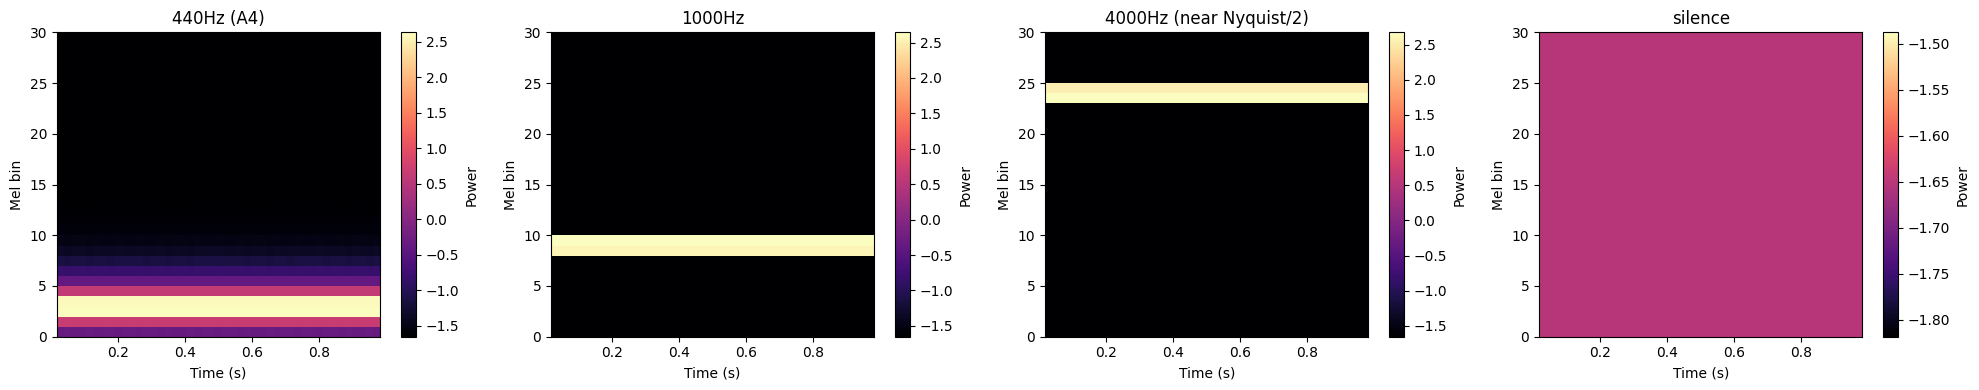


440Hz (A4):
  shape: (30, 45)
  min/max: -1.6530 / 2.6308
  peak mel bin: 2 (of 30)

1000Hz:
  shape: (30, 45)
  min/max: -1.6530 / 2.6442
  peak mel bin: 9 (of 30)

4000Hz (near Nyquist/2):
  shape: (30, 45)
  min/max: -1.6530 / 2.6735
  peak mel bin: 23 (of 30)

silence:
  shape: (30, 45)
  min/max: -1.6530 / -1.6530
  peak mel bin: 0 (of 30)


In [3]:
SIGNAL_LEN = 1 * AUDIO_SAMPLE_RATE_HZ # 1 Second

import matplotlib.pyplot as plt

def make_tone(freq_hz, length=SIGNAL_LEN, sample_rate=AUDIO_SAMPLE_RATE_HZ, amplitude=0.5):
    t = np.arange(length) / sample_rate
    return (amplitude * np.sin(2 * np.pi * freq_hz * t)).astype(np.float32)

AUDIO_SPECTROGRAM_STRIDE_LEN = 352  # 22 ms at 16000 Hz

def plot_spectrogram(spec, title="", sample_rate=AUDIO_SAMPLE_RATE_HZ,
                      frame_len=AUDIO_SPECTROGRAM_FRAME_LEN,
                      stride_len=AUDIO_SPECTROGRAM_STRIDE_LEN, ax=None):
    """
    spec: np.ndarray of shape (n_mels, n_frames), as returned by
    AudioPreprocessor.compute_spectrogram()
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    hop_seconds = stride_len / sample_rate
    n_frames = spec.shape[1]

    # Each column represents a frame_len-sample window starting at i*stride.
    # Label the x-axis by each frame's center time for a more honest
    # representation of overlapping windows -- last frame's window still
    # extends past the final tick, that's expected with overlap.
    frame_center_offset = (frame_len / sample_rate) / 2
    t_start = frame_center_offset
    t_end = (n_frames - 1) * hop_seconds + frame_center_offset
    extent = [t_start, t_end, 0, spec.shape[0]]

    im = ax.imshow(spec, aspect="auto", origin="lower", extent=extent, cmap="magma")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mel bin")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Power")
    return ax


def plot_all_test_signals(preproc, test_signals):
    n = len(test_signals)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, sig) in zip(axes, test_signals.items()):
        spec = preproc.compute_spectrogram(sig)
        plot_spectrogram(spec, title=name, ax=ax)
    plt.tight_layout()
    plt.show()

def run_test_signal():
    preproc = AudioPreprocessor("./build/audioproc-build/libAudioPreprocessing.dylib")
    
    test_signals = {
        "440Hz (A4)": make_tone(440),
        "1000Hz": make_tone(1000),
        "4000Hz (near Nyquist/2)": make_tone(4000),
        "silence": np.zeros(SIGNAL_LEN, dtype=np.float32),
    }
    
    plot_all_test_signals(preproc, test_signals)
    
    for name, sig in test_signals.items():
        spec = preproc.compute_spectrogram(sig)
        print(f"\n{name}:")
        print(f"  shape: {spec.shape}")
        print(f"  min/max: {spec.min():.4f} / {spec.max():.4f}")
        # which mel bin has the most energy, averaged across time columns
        mean_per_mel = spec.mean(axis=1)
        peak_mel_bin = np.argmax(mean_per_mel)
        print(f"  peak mel bin: {peak_mel_bin} (of {spec.shape[0]})")

run_test_signal()

# Load Dataset

In [4]:
import os.path
import re
import sys
import tarfile

import urllib
import tensorflow as tf

from tensorflow.python.platform import gfile

DATA_URL = 'https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz'
DATA_DIR = './dataset'
FS = 16000

def maybe_download_and_extract_dataset(data_url, dest_directory):
    """Download and extract data set tar file.
    
    If the data set we're using doesn't already exist, this function
    downloads it from the TensorFlow.org website and unpacks it into a
    directory.
    If the data_url is none, don't download anything and expect the data
    directory to contain the correct files already.
    
    Args:
      data_url: Web location of the tar file containing the data set.
      dest_directory: File path to extract data to.
    """
    if not data_url:
        return
    if not gfile.Exists(dest_directory):
        os.makedirs(dest_directory)
    filename = data_url.split('/')[-1]
    filepath = os.path.join(dest_directory, filename)
    if not gfile.Exists(filepath):
    
        def _progress(count, block_size, total_size):
            percent = float(count * block_size) / float(total_size) * 100.0
            # Only print when the integer percentage changes
            if percent - _progress.last_percent >= 1.0 or percent >= 100.0:
                sys.stdout.write('\r>> Downloading %s %.1f%%' % (filename, percent))
                sys.stdout.flush()
                _progress.last_percent = percent


        _progress.last_percent = 0.0
    
        try:
            filepath, _ = urllib.request.urlretrieve(data_url, filepath, _progress)
        except:
            tf.compat.v1.logging.error(
                'Failed to download URL: {0} to folder: {1}. Please make sure you '
                'have enough free space and an internet connection'.format(
                data_url, filepath))
            raise
        print()
        statinfo = os.stat(filepath)
        tf.compat.v1.logging.info(
            'Successfully downloaded {0} ({1} bytes)'.format(
                filename, statinfo.st_size))
        tarfile.open(filepath, 'r:gz').extractall(dest_directory)

maybe_download_and_extract_dataset(DATA_URL, DATA_DIR)

# Preprocess Dataset

## Generate more background noise

In [5]:
"""
Generate colored noise (white, pink, brown, blue, violet) as .wav files.

Colored noise is generated by shaping the frequency spectrum of white
noise with a power law: PSD(f) ~ f^beta

    white   -> beta =  0   (flat spectrum)
    pink    -> beta = -1   (energy falls off as 1/f)
    brown   -> beta = -2   (energy falls off as 1/f^2), aka "red" noise
    blue    -> beta = +1   (energy rises with f)
    violet  -> beta = +2   (energy rises with f^2), aka "purple" noise

This is useful as an augmentation for KWS / audio classification datasets,
since it diversifies the kinds of background noise the model has to be
robust against beyond a single white-noise sample.
"""

import numpy as np
import soundfile as sf
import pathlib

# --- Config ------------------------------------------------------------
DST_DIR = pathlib.Path("dataset/_background_noise_")
SAMPLE_RATE = 16000          # match your existing dataset's sample rate
DURATION_SECONDS = 360        # length of each generated noise file
NOISE_COLORS = {
    "white": 0,
    "pink": -1,
    "brown": -2,
    "blue": 1,
    "violet": 2,
}
SEED = 42  # set to None for non-reproducible output
# -------------------------------------------------------------------------


def generate_colored_noise(n_samples: int, beta: float, rng: np.random.Generator) -> np.ndarray:
    """Generate colored noise of length n_samples with PSD ~ f^beta."""
    # Start from white noise in the frequency domain (random phase + magnitude)
    n_freqs = n_samples // 2 + 1
    white_spectrum = rng.normal(size=n_freqs) + 1j * rng.normal(size=n_freqs)

    # Build the frequency scaling. Avoid division by zero at f=0 (DC term).
    freqs = np.arange(1, n_freqs + 1, dtype=np.float64)
    scale = freqs ** (beta / 2.0)  # sqrt because we're scaling amplitude, not power

    shaped_spectrum = white_spectrum * scale
    shaped_spectrum[0] = 0.0  # zero out DC offset

    # Back to time domain
    noise = np.fft.irfft(shaped_spectrum, n=n_samples)

    # Normalize to [-1, 1] so it's a valid float32 wav signal
    noise = noise / np.max(np.abs(noise))
    return noise.astype(np.float32)


def main():
    DST_DIR.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(SEED)
    n_samples = int(SAMPLE_RATE * DURATION_SECONDS)

    for name, beta in NOISE_COLORS.items():
        out_path = DST_DIR / f"{name}_noise.wav"
        
        if pathlib.Path(out_path).exists():
            print(f"Skipping creating {out_path}, exists already")
            continue
            
        noise = generate_colored_noise(n_samples, beta, rng)
        
        sf.write(out_path, noise, SAMPLE_RATE)
        print(f"Wrote {out_path} ({DURATION_SECONDS}s, beta={beta})")


if __name__ == "__main__":
    main()

Skipping creating dataset/_background_noise_/white_noise.wav, exists already
Skipping creating dataset/_background_noise_/pink_noise.wav, exists already
Skipping creating dataset/_background_noise_/brown_noise.wav, exists already
Skipping creating dataset/_background_noise_/blue_noise.wav, exists already
Skipping creating dataset/_background_noise_/violet_noise.wav, exists already


## Split Background noise into 1 second pieces

In [6]:
"""
Split all .wav files in dataset/_background_noise_/ into exactly
1-second-long chunks, saving them to dataset/_background_noise_split_/.

Output naming: <original_stem>_<chunk_index>.wav
e.g. "white_noise.wav" -> "white_noise_0.wav", "white_noise_1.wav", ...

Any leftover audio shorter than 1 second at the end of a file is dropped
by default (see `drop_incomplete_tail` below) so every output chunk is
exactly the same length — useful for KWS pipelines where you want fixed
shape tensors.
"""

import soundfile as sf
import numpy as np
from pathlib import Path

# --- Config ---------------------------------------------------------------
SRC_DIR = Path("dataset/_background_noise_")
DST_DIR = Path("dataset/_background_noise_split_")
CHUNK_SECONDS = 1.0
DROP_INCOMPLETE_TAIL = True  # if False, the final short chunk is zero-padded
# ---------------------------------------------------------------------------


def split_wav_file(wav_path: Path, dst_dir: Path, chunk_seconds: float = 1.0,
                    drop_incomplete_tail: bool = True) -> int:
    """Split a single wav file into fixed-length chunks. Returns chunk count."""
    audio, sample_rate = sf.read(wav_path, always_2d=False)
    # If stereo, audio will be shape (n_samples, n_channels)
    chunk_len = int(round(chunk_seconds * sample_rate))
    total_samples = audio.shape[0]

    n_full_chunks = total_samples // chunk_len
    n_chunks = n_full_chunks
    remainder = total_samples - n_full_chunks * chunk_len

    if remainder > 0 and not drop_incomplete_tail:
        n_chunks += 1

    stem = wav_path.stem
    for i in range(n_chunks):
        start = i * chunk_len
        end = start + chunk_len
        chunk = audio[start:end]

        # Zero-pad the final chunk if it's shorter than chunk_len
        if chunk.shape[0] < chunk_len:
            pad_width = chunk_len - chunk.shape[0]
            if chunk.ndim == 1:
                chunk = np.pad(chunk, (0, pad_width))
            else:
                chunk = np.pad(chunk, ((0, pad_width), (0, 0)))

        out_path = dst_dir / f"{stem}_{i}.wav"
        sf.write(out_path, chunk, sample_rate)

    return n_chunks


def main():
    if DST_DIR.is_dir():
        print("Split dir exists already, exiting")
        return
        
    DST_DIR.mkdir(parents=True, exist_ok=True)

    wav_files = sorted(SRC_DIR.glob("*.wav"))
    if not wav_files:
        print(f"No .wav files found in {SRC_DIR.resolve()}")
        return

    total_chunks = 0
    for wav_path in wav_files:
        n_chunks = split_wav_file(
            wav_path, DST_DIR,
            chunk_seconds=CHUNK_SECONDS,
            drop_incomplete_tail=DROP_INCOMPLETE_TAIL,
        )
        total_chunks += n_chunks
        print(f"{wav_path.name}: {n_chunks} chunks")

    print(f"\nDone. Wrote {total_chunks} chunks to {DST_DIR.resolve()}")


main()

Split dir exists already, exiting


## Split dataset based on new keywords

### Subsample other group to get even classes

In [7]:
def subsample_other_by_group(files, labels, group_ids, other_label,
                              target_other_fraction=0.2, seed=0):
    """
    Subsample the 'other' class at the participant-group level so it makes up
    roughly `target_other_fraction` of the total dataset, while keeping all
    desired-keyword samples untouched and never splitting a group's files
    across the kept/dropped boundary.

    Returns filtered (files, labels, group_ids), plus the keep_mask used.
    """
    rng = np.random.default_rng(seed=seed)

    desired_mask = labels != other_label
    other_mask = ~desired_mask
    desired_count = desired_mask.sum()

    # other / (desired + other) = target_other_fraction
    # => other = desired * target_other_fraction / (1 - target_other_fraction)
    target_other_count = int(desired_count * target_other_fraction / (1 - target_other_fraction))

    print(f"Desired-keyword samples: {desired_count}")
    print(f"Target 'other' samples ({target_other_fraction:.0%} of total): "
          f"{target_other_count} (currently {other_mask.sum()})")

    other_groups = group_ids[other_mask]
    unique_other_groups = np.unique(other_groups)
    rng.shuffle(unique_other_groups)

    group_sizes = {g: np.sum(other_groups == g) for g in unique_other_groups}
    kept_other_groups = []
    running_total = 0
    for g in unique_other_groups:
        if running_total >= target_other_count:
            break
        kept_other_groups.append(g)
        running_total += group_sizes[g]

    kept_other_groups = set(kept_other_groups)
    other_keep_mask = np.array([g in kept_other_groups for g in group_ids]) & other_mask

    keep_mask = desired_mask | other_keep_mask

    filtered_labels = labels[keep_mask]
    actual_other = (filtered_labels == other_label).sum()
    print(f"Actual 'other' samples after subsampling: {actual_other}")
    print(f"Total samples after subsampling: {len(filtered_labels)} "
          f"('other' fraction = {actual_other / len(filtered_labels):.3f})")

    return files[keep_mask], filtered_labels, group_ids[keep_mask], keep_mask

### Split

In [8]:
import pathlib
import re
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
import tensorflow as tf

DATA_DIR = pathlib.Path(DATA_DIR)

IGNORE_DIRS = ['_background_noise_']

# 1. List every file with its original class name + participant id
all_files = []
all_class_names = []
all_group_ids = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    if class_dir.name in IGNORE_DIRS:
        print(f'Skipping dir {class_dir.name}, in IGNORE_DIRS')
        continue

    for f in class_dir.glob('*.wav'):
        if class_dir.name == '_background_noise_split_':
            class_name = '_background_noise_'
        else:
            class_name = class_dir.name

        
        all_files.append(str(f))
        all_class_names.append(class_name)

        if class_name == '_background_noise_':
            # No participant id -- treat each file as its own group
            # so it's free to land in any split independently.
            group_id = f.stem  # unique per file
        else:
            # Filename like 3b3d2f59_nohash_2.wav -> participant id is the first token
            group_id = f.stem.split('_')[0]

        all_group_ids.append(group_id)

all_files = np.array(all_files)
all_group_ids = np.array(all_group_ids)

label_names = np.array(sorted(set(all_class_names)))
class_to_idx = {name: i for i, name in enumerate(label_names)}
orig_labels = np.array([class_to_idx[c] for c in all_class_names])

# 2. Build your mapping exactly as before
DESIRED_KEYWORDS = ['forward', 'backward', 'stop']
DESIRED_KEYWORDS.append('_background_noise_')
OTHER_LABEL = len(DESIRED_KEYWORDS)

mapping = np.full(len(label_names), OTHER_LABEL, dtype=np.int64)
for orig_idx, name in enumerate(label_names):
    if name in DESIRED_KEYWORDS:
        mapping[orig_idx] = DESIRED_KEYWORDS.index(name)

new_labels = mapping[orig_labels]

# 3 Subsample other group to correct percentage of samples

all_files, new_labels, all_group_ids, _ = subsample_other_by_group(
    all_files, new_labels, all_group_ids,
    other_label=OTHER_LABEL,
    target_other_fraction=0.2,
    seed=0)

# 4. Group-aware, label-stratified 3-way split
# StratifiedGroupKFold keeps each group entirely within one fold while
# also trying to balance label proportions across folds.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)  # ~20% per fold
train_idx, temp_idx = next(sgkf.split(all_files, new_labels, groups=all_group_ids))

# Split temp_idx again into val/test, still respecting groups
temp_files = all_files[temp_idx]
temp_labels = new_labels[temp_idx]
temp_groups = all_group_ids[temp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=0)
val_sub_idx, test_sub_idx = next(sgkf2.split(temp_files, temp_labels, groups=temp_groups))

train_files, train_labels = all_files[train_idx], new_labels[train_idx]
val_files, val_labels = temp_files[val_sub_idx], temp_labels[val_sub_idx]
test_files, test_labels = temp_files[test_sub_idx], temp_labels[test_sub_idx]

# 5. Sanity checks
def summarize(name, files, labels, groups):
    print(f"{name}: {len(files)} files, label dist = {dict(zip(*np.unique(labels, return_counts=True)))}")

summarize("train", train_files, train_labels, all_group_ids[train_idx])
summarize("val", val_files, val_labels, temp_groups[val_sub_idx])
summarize("test", test_files, test_labels, temp_groups[test_sub_idx])

# Confirm no participant overlap across splits (excluding background noise's synthetic per-file groups)
train_groups = set(all_group_ids[train_idx])
val_groups = set(temp_groups[val_sub_idx])
test_groups = set(temp_groups[test_sub_idx])
print("train/val overlap:", train_groups & val_groups)
print("train/test overlap:", train_groups & test_groups)
print("val/test overlap:", val_groups & test_groups)

# Labels
new_label_names = np.array(DESIRED_KEYWORDS + ['other'])
orig_label_names = label_names
label_names = new_label_names

print("New label names: ", label_names)
print("Orig label names: ", orig_label_names)

Skipping dir _background_noise_, in IGNORE_DIRS
Desired-keyword samples: 8571
Target 'other' samples (20% of total): 2142 (currently 98736)
Actual 'other' samples after subsampling: 2156
Total samples after subsampling: 10727 ('other' fraction = 0.201)
train: 8532 files, label dist = {np.int64(0): np.int64(1229), np.int64(1): np.int64(1303), np.int64(2): np.int64(3127), np.int64(3): np.int64(1178), np.int64(4): np.int64(1695)}
val: 1148 files, label dist = {np.int64(0): np.int64(172), np.int64(1): np.int64(176), np.int64(2): np.int64(375), np.int64(3): np.int64(146), np.int64(4): np.int64(279)}
test: 1047 files, label dist = {np.int64(0): np.int64(156), np.int64(1): np.int64(185), np.int64(2): np.int64(370), np.int64(3): np.int64(154), np.int64(4): np.int64(182)}
train/val overlap: set()
train/test overlap: set()
val/test overlap: set()
New label names:  ['forward' 'backward' 'stop' '_background_noise_' 'other']
Orig label names:  ['_background_noise_' 'backward' 'bed' 'bird' 'cat' 'do

## Load Preprocessing Lib

In [9]:
preproc = AudioPreprocessor("./build/audioproc-build/libAudioPreprocessing.dylib")

## Audio WAV File Loading

In [10]:
def load_wav(file_path, label):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1, desired_samples=16000)
    audio = tf.squeeze(audio, axis=-1)  # replaces your old `squeeze` map step
    return audio, label

## Check some spectrograms

2026-09-11 12:08:57.895843: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-09-11 12:08:57.895868: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-11 12:08:57.895875: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1789142937.895889 11817336 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1789142937.895906 11817336 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


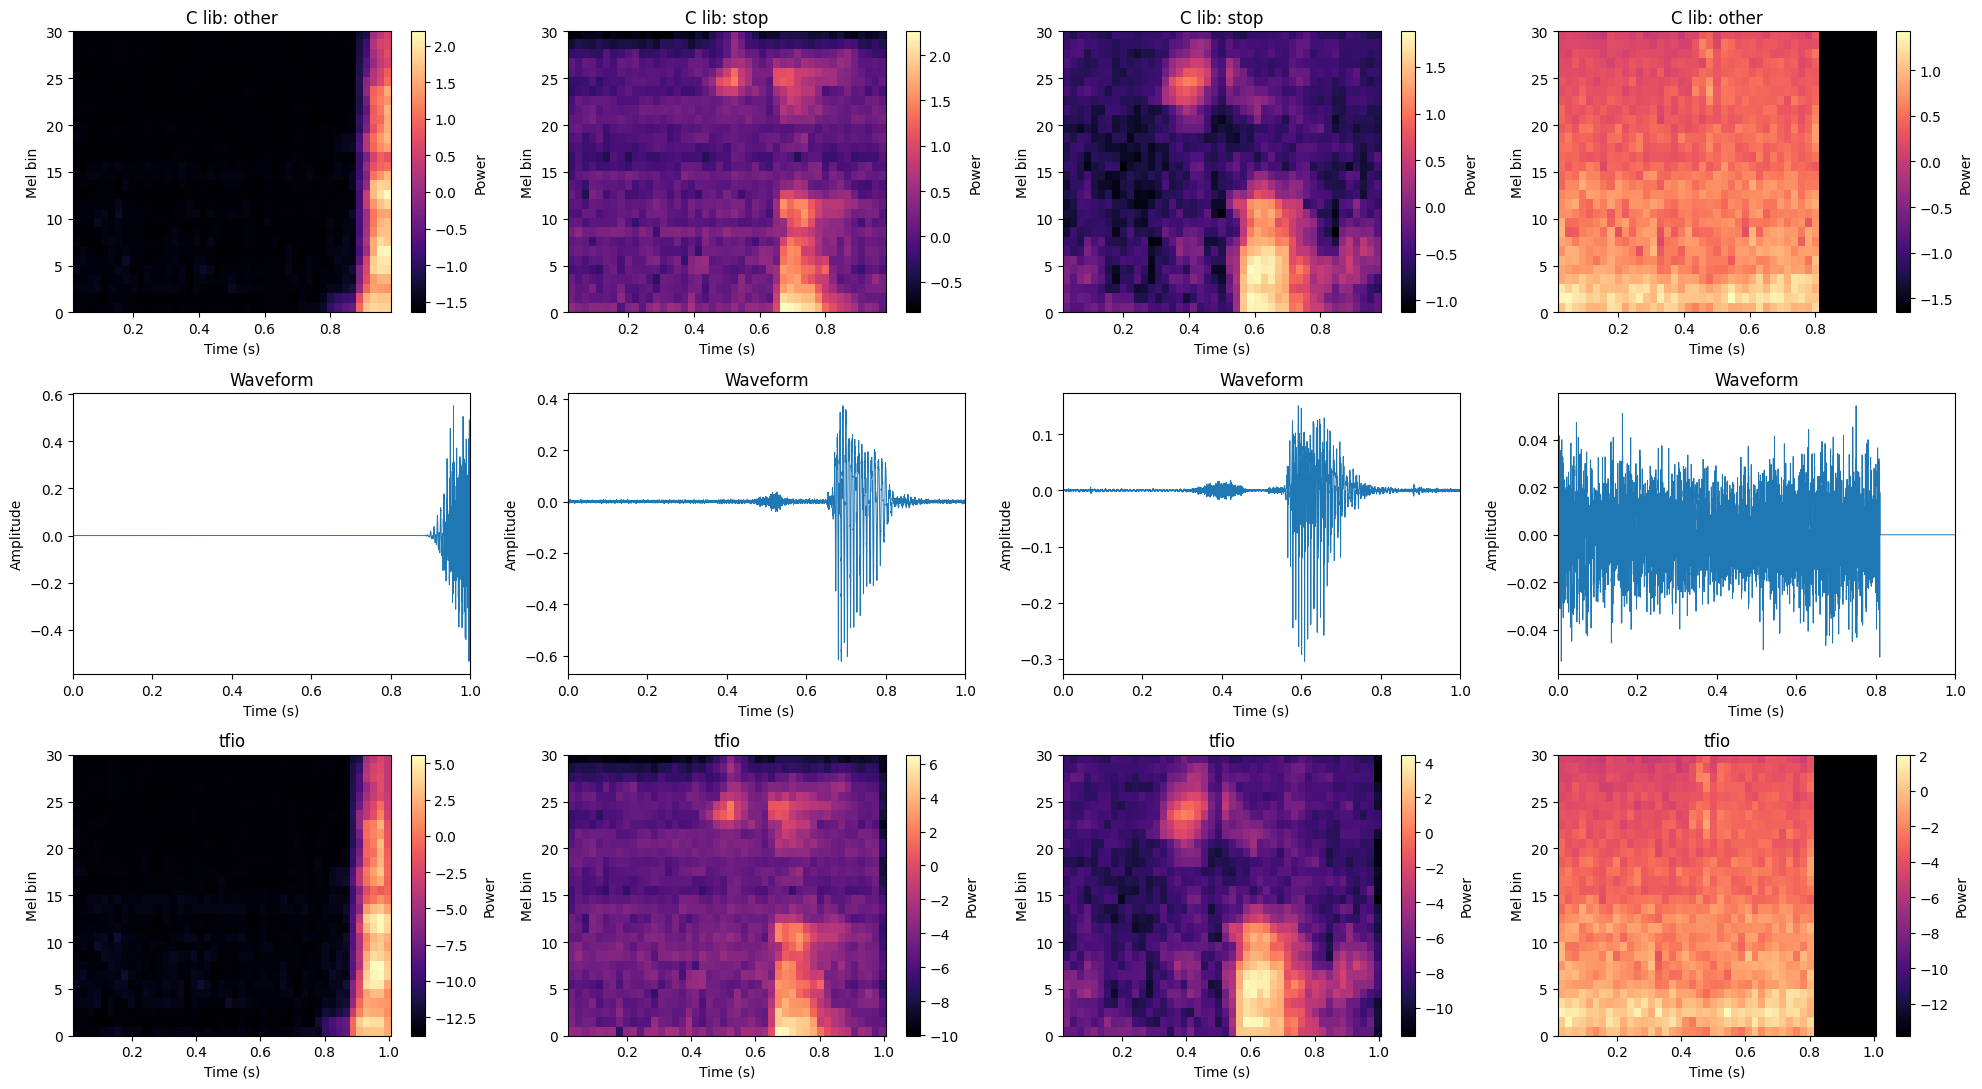

In [11]:
import random
import tensorflow_io as tfio

LOG_EPSILON = 1e-6

def get_spectrogram(waveform):
    return tfio.audio.spectrogram(waveform, nfft=512, window=512, stride=352)
def get_mel_spectrogram(spectrogram, fs):
    return tfio.audio.melscale(spectrogram, rate=fs, mels=30, fmin=125, fmax=7500)

def compare_spectrograms(file_paths, labels, preproc, n_samples=4,
                          label_names=None, seed=None,
                          sample_rate=AUDIO_SAMPLE_RATE_HZ):
    rng = random.Random(seed)
    indices = rng.sample(range(len(file_paths)), n_samples)

    fig, axes = plt.subplots(3, n_samples, figsize=(5 * n_samples, 11))
    if n_samples == 1:
        axes = axes.reshape(3, 1)

    for col, idx in enumerate(indices):
        audio_tensor, label = load_wav(file_paths[idx], labels[idx])
        audio_np = audio_tensor.numpy().astype(np.float32)
        label_val = int(label.numpy()) if hasattr(label, "numpy") else int(label)
        label_str = label_names[label_val] if label_names is not None else str(label_val)

        # --- C library spectrogram ---
        c_spec = preproc.compute_spectrogram(audio_np)

        # --- tfio spectrogram ---
        tfio_stft = get_spectrogram(audio_tensor)          # shape (frames, nfft/2+1), magnitude
        tfio_power = tf.square(tfio_stft)                  # square to match SPECTRUM_TYPE_POWER
        tfio_mel = get_mel_spectrogram(tfio_power, fs=sample_rate)
        tfio_mel_np = tfio_mel.numpy().T                   # (frames, mels) -> (mels, frames)

        # Convert to log scale, matching the C side's log(mel + epsilon)
        tfio_mel_np = np.log(tfio_mel_np + LOG_EPSILON)

        # Row 0: C library spectrogram
        plot_spectrogram(c_spec, title=f"C lib: {label_str}", ax=axes[0, col])

        # Row 1: raw waveform, time-aligned
        t = np.arange(len(audio_np)) / sample_rate
        axes[1, col].plot(t, audio_np, linewidth=0.7)
        axes[1, col].set_xlim(0, len(audio_np) / sample_rate)
        axes[1, col].set_xlabel("Time (s)")
        axes[1, col].set_ylabel("Amplitude")
        axes[1, col].set_title("Waveform")

        # Row 2: tfio spectrogram
        plot_spectrogram(tfio_mel_np, title="tfio", ax=axes[2, col])

    plt.tight_layout()
    plt.show()

compare_spectrograms(train_files, train_labels, preproc, n_samples=4,
                      label_names=label_names, seed=45)

## Load clips and preprocess into datasets

In [12]:
def build_spectrogram_dataset(file_paths, labels, preproc, augment=False, augment_passes=1):
    # Reuse existing TF-based wav loading, run eagerly to get raw numpy clips
    raw_ds = (tf.data.Dataset.from_tensor_slices((file_paths, labels))
              .map(load_wav, num_parallel_calls=tf.data.AUTOTUNE))

    specs = []
    spec_labels = []

    for audio, label in raw_ds.as_numpy_iterator():
        n_passes = augment_passes if augment else 1
        for _ in range(n_passes):
            processed = augment_clip(audio) if augment else audio
            spec = preproc.compute_spectrogram(processed)
            specs.append(spec.astype(np.float32))
            spec_labels.append(label)

    specs = np.stack(specs)
    spec_labels = np.array(spec_labels)
    return tf.data.Dataset.from_tensor_slices((specs, spec_labels))


def augment_clip(clip):
    """Placeholder -- currently a no-op. Fill in later with noise mixing,
    time-shift, etc. when you add augmentation."""
    return clip



train_ds = build_spectrogram_dataset(train_files, train_labels, preproc, augment=False)
val_ds   = build_spectrogram_dataset(val_files, val_labels, preproc, augment=False)
test_ds  = build_spectrogram_dataset(test_files, test_labels, preproc, augment=False)

2026-09-11 12:09:03.934137: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-09-11 12:09:04.609810: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Visualize Spectrograms

2026-09-11 12:09:05.262911: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


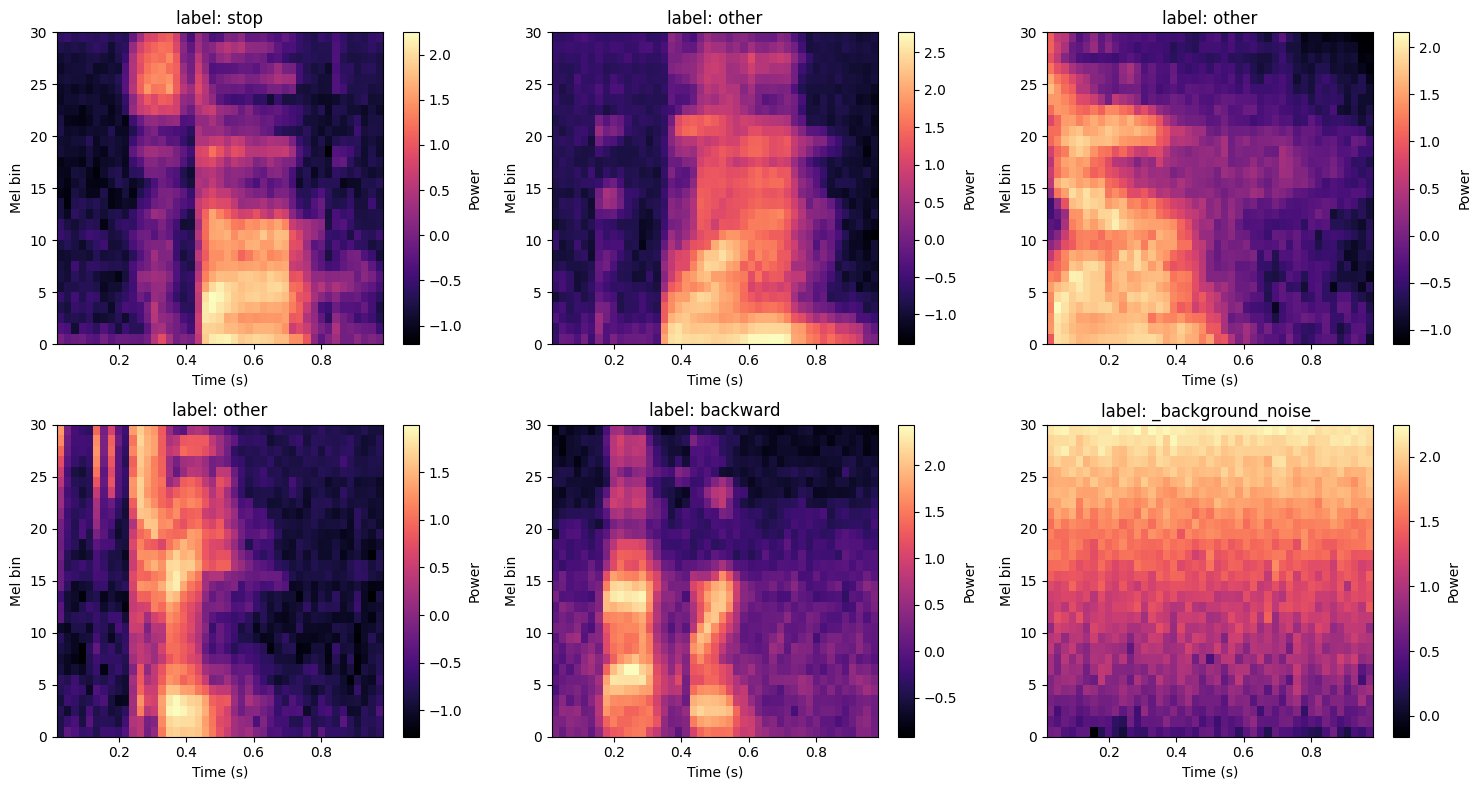

In [13]:
def visualize_dataset_samples(dataset, n_samples=6, label_names=None, seed=None):
    """
    dataset: unbatched tf.data.Dataset yielding (spectrogram, label) pairs,
    as returned by build_spectrogram_dataset(). Call this BEFORE .batch().
    """
    # Shuffle with a buffer covering the full dataset so `take` isn't biased
    # toward whatever ordering the dataset happens to be in (e.g. all
    # background noise first). Since your dataset is small (~10k clips),
    # a full-size buffer is cheap.
    cardinality = dataset.cardinality().numpy()
    buffer_size = cardinality if cardinality > 0 else 10000  # fallback if unknown
    shuffled = dataset.shuffle(buffer_size, seed=seed)

    samples = list(shuffled.take(n_samples).as_numpy_iterator())

    n = len(samples)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (spec, label) in zip(axes, samples):
        label_str = label_names[label] if label_names is not None else str(label)
        plot_spectrogram(spec, title=f"label: {label_str}", ax=ax)

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Usage:
visualize_dataset_samples(train_ds, n_samples=6, label_names=label_names, seed=42)

### Calculate Norm Stats

In [14]:
def compute_norm(train_ds):
    norm_layer = layers.Normalization(axis=None)
    norm_layer.adapt(data=train_ds.map(lambda spec, label: spec))

    mean = float(norm_layer.mean.numpy().squeeze())
    variance = float(norm_layer.variance.numpy().squeeze())
    
    return mean, variance

mean, variance = compute_norm(train_ds)

print(f"Mean {mean}, Variance {variance}")

Mean -1.2647360563278198e-06, Variance 0.9999991059303284


## Finalize Dataset

In [15]:
BATCH_SIZE = 1024
SHUFFLE_BUFFER_SIZE = 10000 # Needs to be >= train dataset size

# --- Step 4: Batch/cache/prefetch as usual, downstream of normalization ---
train_ds = (train_ds
    .cache()
    .shuffle(SHUFFLE_BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Convert Dataset to .npz for ST AI Tools

In [16]:
import numpy as np
import tensorflow as tf

def dataset_to_npz(dataset, output_path, num_classes):
    x_batches = []
    y_batches = []

    for x_batch, y_batch in dataset:
        x_batches.append(x_batch.numpy())
        y_onehot = tf.one_hot(y_batch, num_classes)
        y_batches.append(y_onehot.numpy())

    x_test = np.concatenate(x_batches, axis=0)
    y_test = np.concatenate(y_batches, axis=0)

    np.savez(output_path, x_test=x_test, y_test=y_test)
    return x_test, y_test

x_test, y_test = dataset_to_npz(test_ds, "TestDatasetST/test_ds.npz", num_classes=5)
print(x_test.shape, y_test.shape)

(1047, 30, 45) (1047, 5)


# Model

In [17]:
EPOCHS = 125

def gen_model(epochs):
    initial_lr = 0.0002975779176889909
    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    
    decay_steps = epochs * steps_per_epoch
    
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=decay_steps,
        alpha=0.00278240528522536,  # final LR = initial_lr * alpha
    )
    
    
    for example_spectrograms, example_spect_labels in train_ds.take(1):
      break
    
    input_shape = example_spectrograms.shape[1:]
    print('Input shape:', input_shape)
    num_labels = len(label_names)
    print('Labels: ', label_names)
    
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Reshape(input_shape + (1,)),  # (30, 45) -> (30, 45, 1)
        
        # Convolutional layer (bias is set to False because BatchNorm adds its own beta bias parameter)
        # layers.Conv2D(filters=48, kernel_size=(3, 3), padding='same', use_bias=False),
        layers.Conv2D(filters=48, kernel_size=(3, 3), padding='same', activation='relu'),


        # layers.BatchNormalization(),

        # Non-linear activation (applied after batch normalization)
        # layers.Activation('relu'),
        
        layers.MaxPooling2D(pool_size=(4, 4)),
        
        layers.Flatten(),
        
        layers.Dense(units=48, activation='relu'),
        
        layers.Dense(num_labels),
    ])

    model.summary()


    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

    return model

model = gen_model(EPOCHS)

Input shape: (30, 45)
Labels:  ['forward' 'backward' 'stop' '_background_noise_' 'other']


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 30, 45, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 45, 48)     │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 11, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3696)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │       177,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,181 (696.02 KB)

 Trainable params: 178,181 (696.02 KB)

 Non-trainable params: 0 (0.00 B)

# Train

## Checkpoints

In [18]:
# --- Setup ---
checkpoint_dir = "checkpoints/kws_v4"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "model_epoch{epoch:03d}.keras")

# Also keep a "latest" symlink-style path for easy resume
latest_path = os.path.join(checkpoint_dir, "latest.keras")
# Also keep a "best" symlink-style path for easy resume
best_path = os.path.join(checkpoint_dir, "best.keras")


checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,   # saves full model (architecture + weights + optimizer state)
    save_best_only=False,      # set True if you only want to keep the best val_loss/val_acc
    monitor="val_accuracy",    # relevant if save_best_only=True
    save_freq="epoch",
    verbose=1,
)

best_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=best_path,
    save_weights_only=False,   # saves full model (architecture + weights + optimizer state)
    save_best_only=True,      # set True if you only want to keep the best val_loss/val_acc
    monitor="val_accuracy",    # relevant if save_best_only=True
    save_freq="epoch",
    verbose=1,
)

# Optional: always overwrite a single "latest" file too, useful for quick resume
latest_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=latest_path,
    save_weights_only=False,
    save_freq="epoch",
    verbose=0,
)

## Train

In [19]:
log_dir = "logs/fit/v4/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(verbose=1, patience=15, monitor="accuracy")

callbacks = [tensorboard_callback, checkpoint_callback, latest_callback, best_callback, early_stopping_callback]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/125


2026-09-11 12:09:22.275796: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3164 - loss: 1.5144
Epoch 1: saving model to checkpoints/kws_v4/model_epoch001.keras

Epoch 1: val_accuracy improved from None to 0.39721, saving model to checkpoints/kws_v4/best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3853 - loss: 1.4405 - val_accuracy: 0.3972 - val_loss: 1.3738
Epoch 2/125
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4650 - loss: 1.2815
Epoch 2: saving model to checkpoints/kws_v4/model_epoch002.keras

Epoch 2: val_accuracy improved from 0.39721 to 0.41376, saving model to checkpoints/kws_v4/best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4631 - loss: 1.2650 - val_accuracy: 0.4138 - val_loss: 1.3070
Epoch 3/125
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4788 - loss: 1.2121
Epoch 3: saving model to checkpoints/kws_v4/model_epoch003.keras

Epoch 3: val_accuracy improved from 0.41376 to 0.44774, saving model to checkpoints/kws_v4/best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42m

## Visualize Training

Text(0, 0.5, 'Accuracy [%]')

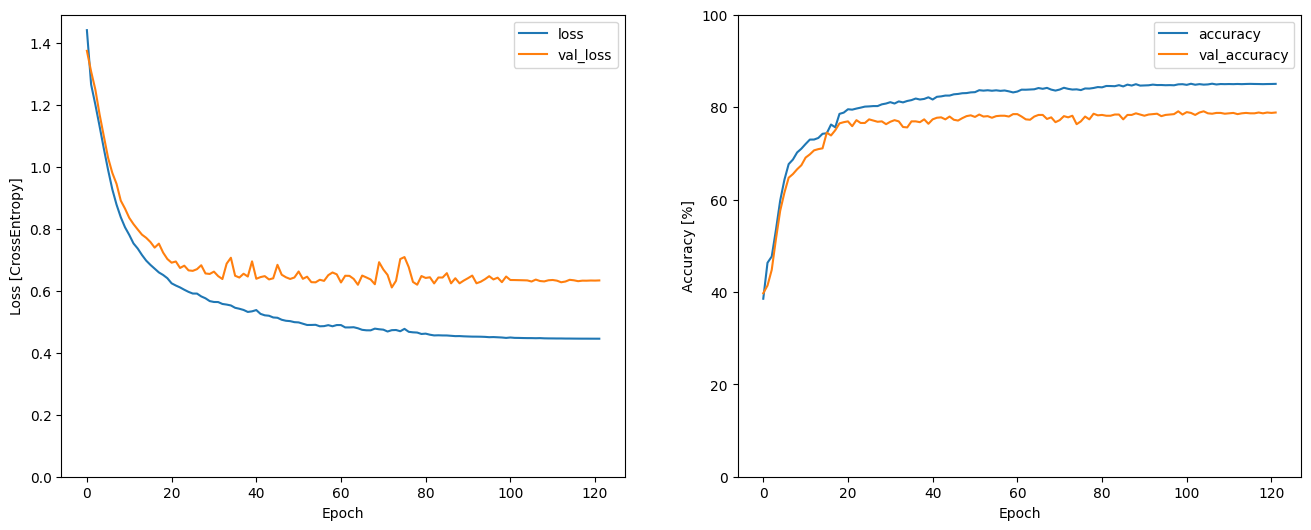

In [20]:
metrics = history.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Epoch')
plt.ylabel('Loss [CrossEntropy]')

plt.subplot(1,2,2)
plt.plot(history.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Epoch')
plt.ylabel('Accuracy [%]')

## Restore Best Model

In [21]:
model = tf.keras.models.load_model(best_path)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 30, 45, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 45, 48)     │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 11, 48)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3696)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │       177,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,544 (2.04 MB)

 Trainable params: 178,181 (696.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 356,363 (1.36 MB)

## Tensorboard

In [22]:
%tensorboard --logdir logs/fit/v4

# Evaluate

Val Eval
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7909 - loss: 0.6276 
Test Eval
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7784 - loss: 0.6243
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


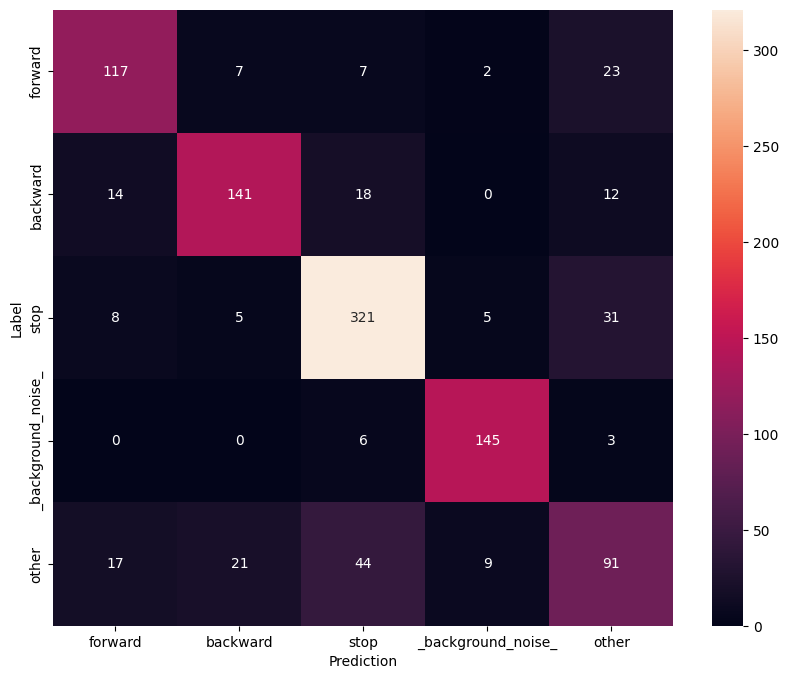

In [23]:
def eval_model():
    print("Val Eval")
    model.evaluate(val_ds, return_dict=True)
    
    print("Test Eval")
    model.evaluate(test_ds, return_dict=True)
    
    y_pred = model.predict(test_ds)
    y_pred = tf.argmax(y_pred, axis=1)
    y_true = tf.concat(list(test_ds.map(lambda s,lab: lab)), axis=0)
    
    confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_mtx,
                xticklabels=new_label_names,
                yticklabels=new_label_names,
                annot=True, fmt='g')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.show()

eval_model()

# Save Model as H5 for ST Tools

In [24]:
model.save("best.h5")

# Quantize

## Quantization Aware Training to Fine Tune

In [25]:
# import tensorflow_model_optimization as tfmot

# def gen_qat_model(float_model, qat_epochs, qat_lr=1e-5):
#     """
#     Wraps a trained float model with fake-quant nodes for QAT fine-tuning.
#     tfmot's default8bit scheme recognizes the Conv2D->BatchNorm->ReLU
#     pattern and simulates the folded/fused int8 op during training,
#     matching what the TFLite converter will actually produce.
#     """
#     quantize_model = tfmot.quantization.keras.quantize_model

#     q_aware_model = quantize_model(float_model)

#     steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
#     decay_steps = qat_epochs * steps_per_epoch

#     lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
#         initial_learning_rate=qat_lr,
#         decay_steps=decay_steps,
#         alpha=0.1,
#     )

#     q_aware_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
#         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#         metrics=['accuracy'],
#     )

#     q_aware_model.summary()

#     return q_aware_model

In [26]:
# QAT_EPOCHS = 10

# q_aware_model = gen_qat_model(model, qat_epochs=QAT_EPOCHS, qat_lr=1e-5)

# q_aware_history = q_aware_model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=QAT_EPOCHS,
# )

## Quantize

In [27]:
def representative_dataset_gen(dataset, num_calibration_steps=200):
    """
    dataset: a batched tf.data.Dataset (e.g. train_ds), already normalized.
    Yields single-example, float32 batches for calibration.
    """
    for spectrogram, _ in dataset.unbatch().take(num_calibration_steps):
        sample = tf.expand_dims(spectrogram, axis=0)
        yield [tf.cast(sample, tf.float32)]


def representative_dataset_gen_stratified(dataset, num_classes,
                                            samples_per_class=40):
    """
    Stratified version: pulls roughly equal samples per class from
    the (already normalized) dataset. Unbatches first since train_ds
    is batched at 1024.
    """
    counts = {i: 0 for i in range(num_classes)}
    target = samples_per_class

    for spectrogram, label in dataset.unbatch():
        label_idx = int(label.numpy())
        if counts[label_idx] < target:
            sample = tf.expand_dims(spectrogram, axis=0)
            yield [tf.cast(sample, tf.float32)]
            counts[label_idx] += 1
        if all(c >= target for c in counts.values()):
            break


def convert_to_tflite_int8(model, representative_dataset_fn, output_path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.representative_dataset = representative_dataset_fn

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(output_path, "wb") as f:
        f.write(tflite_model)

    print(f"Saved quantized model to {output_path}")
    print(f"Model size: {len(tflite_model) / 1024:.1f} KB")

    return tflite_model


# --- Usage ---
num_labels = len(label_names)

tflite_model = convert_to_tflite_int8(
    model=model,
    representative_dataset_fn=lambda: representative_dataset_gen_stratified(
        train_ds, num_classes=num_labels, samples_per_class=40
    ),
    output_path="tflite_models/kws_v4_int8.tflite",
)

INFO:tensorflow:Assets written to: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmp33bseqtm/assets


INFO:tensorflow:Assets written to: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmp33bseqtm/assets


Saved artifact at '/var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmp33bseqtm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 45), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  6038975088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038210160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038213680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038442880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038440944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038443584: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/richardmatthews/miniconda3/envs/kws/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1789143011.145479 11817336 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1789143011.145496 11817336 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-09-11 12:10:11.145705: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmp33bseqtm
2026-09-11 12:10:11.146007: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-09-11 12:10:11.146011: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmp33bseqtm
I0000 00:00:1789143011.147922 11817336 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-09-1

Saved quantized model to tflite_models/kws_v4_int8.tflite
Model size: 181.0 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## Convert to tflite, no quantize

In [28]:
def convert_to_tflite_float32(model, output_path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    tflite_model = converter.convert()

    with open(output_path, "wb") as f:
        f.write(tflite_model)

    print(f"Saved float32 model to {output_path}")
    print(f"Model size: {len(tflite_model) / 1024:.1f} KB")

    return tflite_model


# --- Usage ---
tflite_float_model = convert_to_tflite_float32(
    model=model,
    output_path="tflite_models/kws_v4_float32.tflite",
)

INFO:tensorflow:Assets written to: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmpe6gwb5yd/assets


INFO:tensorflow:Assets written to: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmpe6gwb5yd/assets


Saved artifact at '/var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmpe6gwb5yd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 45), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  6038975088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038210160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038213680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038442880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038440944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6038443584: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved float32 model to tflite_models/kws_v4_float32.tflite
Model size: 699.9 KB


W0000 00:00:1789143011.838889 11817336 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1789143011.838903 11817336 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-09-11 12:10:11.838996: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmpe6gwb5yd
2026-09-11 12:10:11.839320: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-09-11 12:10:11.839332: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmpe6gwb5yd
2026-09-11 12:10:11.841310: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-09-11 12:10:11.851946: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/tmpe6gwb5yd
2026-09-11 12:10:11.855630: I tensorflow/cc/saved_model/loader.c

## Validate

### Validate Int8 TFLite

In [29]:
from ai_edge_litert.interpreter import Interpreter

import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

def validate_tflite_model(tflite_path, test_ds, label_names):
    """
    Runs the int8 tflite model over test_ds and returns true/predicted
    labels for further analysis (accuracy, confusion matrix, etc).
    """
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_scale, in_zero_point = input_details['quantization']

    y_true = []
    y_pred = []

    for spectrogram, label in test_ds.unbatch():
        x = spectrogram.numpy()
        x_q = (x / in_scale + in_zero_point).round().astype(input_details['dtype'])
        x_q = np.expand_dims(x_q, axis=0)

        interpreter.set_tensor(input_details['index'], x_q)
        interpreter.invoke()
        out_q = interpreter.get_tensor(output_details['index'])[0]

        pred = np.argmax(out_q)  # argmax unaffected by dequantization
        y_pred.append(pred)
        y_true.append(int(label.numpy()))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = (y_true == y_pred).mean()
    print(f"Int8 model accuracy on test set: {accuracy:.4f} ({(y_true == y_pred).sum()}/{len(y_true)})")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    return y_true, y_pred




# --- Usage ---
y_true, y_pred_int8 = validate_tflite_model("tflite_models/kws_v4_int8.tflite", test_ds, label_names)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Int8 model accuracy on test set: 0.3792 (397/1047)

Classification report:
                    precision    recall  f1-score   support

           forward       0.19      0.05      0.08       156
          backward       0.33      0.16      0.22       185
              stop       0.63      0.22      0.32       370
_background_noise_       0.46      1.00      0.63       154
             other       0.27      0.68      0.39       182

          accuracy                           0.38      1047
         macro avg       0.38      0.42      0.33      1047
      weighted avg       0.42      0.38      0.33      1047



2026-09-11 12:10:12.042027: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Validate Float TFLite

In [30]:
from ai_edge_litert.interpreter import Interpreter

import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

def validate_tflite_model_float(tflite_path, test_ds, label_names):
    """
    Runs the float32 tflite model over test_ds and returns true/predicted
    labels for further analysis (accuracy, confusion matrix, etc).
    """
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    y_true = []
    y_pred = []

    for spectrogram, label in test_ds.unbatch():
        x = spectrogram.numpy().astype(input_details['dtype'])
        x = np.expand_dims(x, axis=0)

        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details['index'])[0]

        pred = np.argmax(out)
        y_pred.append(pred)
        y_true.append(int(label.numpy()))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = (y_true == y_pred).mean()
    print(f"Float model accuracy on test set: {accuracy:.4f} ({(y_true == y_pred).sum()}/{len(y_true)})")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=label_names))

    return y_true, y_pred


# --- Usage ---
y_true, y_pred_float = validate_tflite_model_float(
    "tflite_models/kws_v4_float32.tflite", test_ds, label_names
)

Float model accuracy on test set: 0.3801 (398/1047)

Classification report:
                    precision    recall  f1-score   support

           forward       0.20      0.05      0.08       156
          backward       0.34      0.16      0.22       185
              stop       0.63      0.22      0.33       370
_background_noise_       0.46      1.00      0.63       154
             other       0.27      0.69      0.39       182

          accuracy                           0.38      1047
         macro avg       0.38      0.42      0.33      1047
      weighted avg       0.43      0.38      0.33      1047



### Confusion Matrix

#### Confusion Matrix Int8

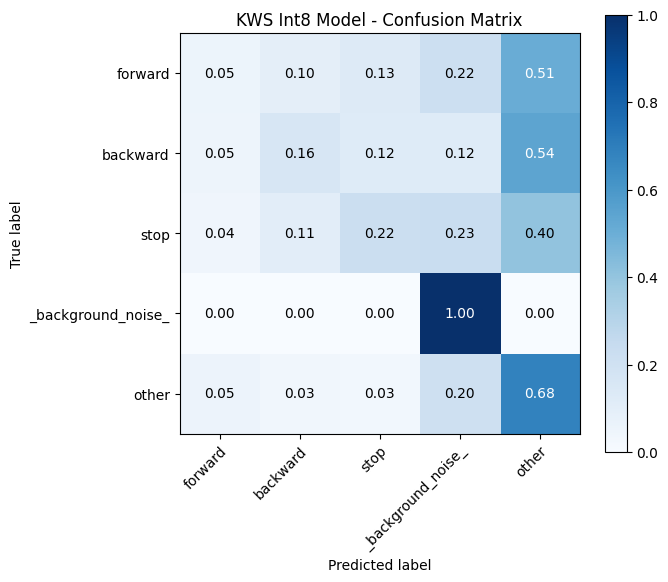

In [31]:
def plot_confusion_matrix(y_true, y_pred, label_names, normalize=True,
                            title="Confusion Matrix", save_path=None):
    """
    Plots a confusion matrix. Set normalize=True to show per-class
    recall (rows sum to 1) rather than raw counts, useful for
    imbalanced classes like your 'background'/'other' vs keyword classes.
    """
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_display = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        cm_display = cm
        fmt = "d"

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_display, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(label_names)),
        yticks=np.arange(len(label_names)),
        xticklabels=label_names,
        yticklabels=label_names,
        ylabel='True label',
        xlabel='Predicted label',
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm_display.max() / 2.0
    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, format(cm_display[i, j], fmt),
                ha="center", va="center",
                color="white" if cm_display[i, j] > thresh else "black",
            )

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    plt.show()

    return cm

cm = plot_confusion_matrix(y_true, y_pred_int8, label_names, normalize=True,
                             title="KWS Int8 Model - Confusion Matrix")

#### Confusion Matrix Float Model

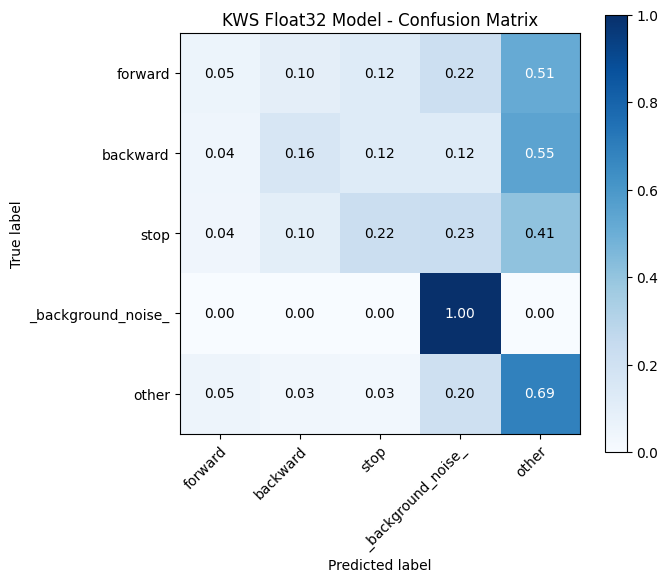

In [32]:
def plot_confusion_matrix(y_true, y_pred, label_names, normalize=True,
                            title="Confusion Matrix", save_path=None):
    """
    Plots a confusion matrix. Set normalize=True to show per-class
    recall (rows sum to 1) rather than raw counts, useful for
    imbalanced classes like your 'background'/'other' vs keyword classes.
    """
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_display = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        cm_display = cm
        fmt = "d"

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_display, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(label_names)),
        yticks=np.arange(len(label_names)),
        xticklabels=label_names,
        yticklabels=label_names,
        ylabel='True label',
        xlabel='Predicted label',
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm_display.max() / 2.0
    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            ax.text(
                j, i, format(cm_display[i, j], fmt),
                ha="center", va="center",
                color="white" if cm_display[i, j] > thresh else "black",
            )

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    plt.show()

    return cm

cm = plot_confusion_matrix(y_true, y_pred_float, label_names, normalize=True,
                             title="KWS Float32 Model - Confusion Matrix")

# Compare TFLite vs Keras

In [33]:
def compare_keras_vs_tflite(keras_model, tflite_path, test_ds, n=10, seed=None):
    interpreter = Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Shuffle with a buffer covering the full dataset so the sample
    # isn't biased toward whatever class appears first in storage order.
    unbatched = test_ds.unbatch()
    total = unbatched.cardinality().numpy()
    if total < 0:  # cardinality unknown (e.g. after certain ops)
        total = sum(1 for _ in unbatched)

    sampled = unbatched.shuffle(buffer_size=total, seed=seed).take(n)

    for i, (spectrogram, label) in enumerate(sampled):
        x_np = spectrogram.numpy()
        # print(f'X_np shape {x_np.shape}')
        # x_np_expanded = np.expand_dims(x_np, axis=0)
        # print(f'X_np_exp shape {x_np_expanded.shape}')


        # Keras
        keras_out = keras_model.predict(np.expand_dims(x_np, axis=0), verbose=0)[0]
        keras_pred = np.argmax(keras_out)

        # TFLite
        x = np.expand_dims(x_np.astype(input_details['dtype']), axis=0)
        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        tflite_out = interpreter.get_tensor(output_details['index'])[0]
        tflite_pred = np.argmax(tflite_out)

        match = "OK" if keras_pred == tflite_pred else "MISMATCH"
        print(f"[{i}] true={int(label.numpy())} keras_pred={keras_pred} "
              f"tflite_pred={tflite_pred} {match}")
        print(f"    keras_out={keras_out}")
        print(f"    tflite_out={tflite_out}")

compare_keras_vs_tflite(model, "tflite_models/kws_v4_float32.tflite", test_ds, n=10)

[0] true=2 keras_pred=2 tflite_pred=2 OK
    keras_out=[-13.5786   -13.180304  -6.103669 -21.70982  -10.957934]
    tflite_out=[-21.62075    -3.6434689  11.362452    1.4168072 -24.003235 ]
[1] true=2 keras_pred=2 tflite_pred=4 MISMATCH
    keras_out=[31.08889  34.30576  39.08753  30.550255 37.0976  ]
    tflite_out=[-25.180653    4.7869854   6.739465  -22.976105   68.07178  ]
[2] true=4 keras_pred=0 tflite_pred=4 MISMATCH
    keras_out=[59.07186  57.06281  55.424805 51.903942 57.692116]
    tflite_out=[-18.61965   28.983097  15.543602 -53.973972 104.57299 ]
[3] true=2 keras_pred=2 tflite_pred=4 MISMATCH
    keras_out=[-2.1081014 -2.6481483  5.24728   -2.5811982  2.6469352]
    tflite_out=[ -5.2917805  -3.0578022   5.477542  -20.270273    6.3484187]
[4] true=2 keras_pred=2 tflite_pred=4 MISMATCH
    keras_out=[ 4.4315305  3.1055052  9.158969  -2.110518   3.8168104]
    tflite_out=[-17.523941   -3.1570578   2.4774876  -7.51256    12.131985 ]
[5] true=2 keras_pred=2 tflite_pred=3 MISMATCH

# Optimize

## Study

In [54]:
import optuna
from optuna.integration import TFKerasPruningCallback
import tensorflow as tf
from tensorflow.keras import layers, models


def build_model(input_shape, num_labels, initial_lr, alpha, conv_filters, dense_units, decay_steps):
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=decay_steps,
        alpha=alpha,
    )

    max_pool_size = (2, 2)
    if dense_units > 32:
        max_pool_size = (4, 4)
        
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Reshape(input_shape + (1,)),  # (30, 45) -> (30, 45, 1)

        # Convolutional layer (bias is set to False because BatchNorm adds its own beta bias parameter)
        layers.Conv2D(filters=conv_filters, kernel_size=(3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        # Non-linear activation (applied after batch normalization)
        layers.Activation('relu'),


            layers.MaxPooling2D(pool_size=max_pool_size),

        layers.Flatten(),

        layers.Dense(units=dense_units, activation='relu'),

        layers.Dense(num_labels),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )
    return model


def objective(trial, train_ds, val_ds, label_names, epochs=100):
    initial_lr = trial.suggest_float('initial_lr', 1e-4, 3e-3, log=True)
    alpha = trial.suggest_float('alpha', 0.001, 0.1, log=True)
    conv_filters = trial.suggest_categorical('conv_filters', [16, 24, 32, 48, 64])
    dense_units = trial.suggest_categorical('dense_units', [8, 16, 32, 48, 64])

    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    decay_steps = epochs * steps_per_epoch

    for example_spectrograms, example_spect_labels in train_ds.take(1):
        break
    input_shape = example_spectrograms.shape[1:]
    num_labels = len(label_names)

    model = build_model(
        input_shape=input_shape,
        num_labels=num_labels,
        initial_lr=initial_lr,
        alpha=alpha,
        conv_filters=conv_filters,
        dense_units=dense_units,
        decay_steps=decay_steps,
    )

    pruning_callback = TFKerasPruningCallback(trial, 'val_loss')
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[pruning_callback, early_stop],
        verbose=0,
    )

    val_accuracy = max(history.history['val_accuracy'])

    # Track model size alongside accuracy for later filtering (STM32U5 deployment budget)
    trial.set_user_attr('param_count', model.count_params())

    return val_accuracy


def run_study(train_ds, val_ds, label_names, n_trials=50, epochs=100):
    study = optuna.create_study(
        direction='maximize',
        pruner=optuna.pruners.PatientPruner(
            optuna.pruners.MedianPruner(
                n_startup_trials=10,
                n_warmup_steps=30,
                interval_steps=5,
            ),
            patience=15,
        ),
    )
    study.optimize(
        lambda trial: objective(trial, train_ds, val_ds, label_names, epochs=epochs),
        n_trials=n_trials,
    )

    print('Best trial:')
    print(f'  Value: {study.best_trial.value}')
    print(f'  Params: {study.best_trial.params}')
    print(f'  Param count: {study.best_trial.user_attrs.get("param_count")}')

    return study


study = run_study(train_ds, val_ds, label_names, n_trials=500, epochs=100)

/var/folders/nr/kyqf2x512c7c496t76xkf0xm0000gn/T/ipykernel_24813/3275605598.py:94: ExperimentalWarning: PatientPruner is experimental (supported from v2.8.0). The interface can change in the future.
  pruner=optuna.pruners.PatientPruner(
[I 2026-09-07 14:25:38,092] A new study created in memory with name: no-name-791631be-9563-497a-89c5-ef004d299c0b
[I 2026-09-07 14:26:44,334] Trial 0 finished with value: 0.7456446290016174 and parameters: {'initial_lr': 0.0007671862596862591, 'alpha': 0.03781546810733475, 'conv_filters': 48, 'dense_units': 48}. Best is trial 0 with value: 0.7456446290016174.
[I 2026-09-07 14:26:59,930] Trial 1 finished with value: 0.46515679359436035 and parameters: {'initial_lr': 0.00115260907433503, 'alpha': 0.01648142201996496, 'conv_filters': 48, 'dense_units': 32}. Best is trial 0 with value: 0.7456446290016174.
[I 2026-09-07 14:27:41,031] Trial 2 finished with value: 0.32752612233161926 and parameters: {'initial_lr': 0.0020264144240181607, 'alpha': 0.00201458736

Best trial:
  Value: 0.8275261521339417
  Params: {'initial_lr': 0.0002975779176889909, 'alpha': 0.00278240528522536, 'conv_filters': 48, 'dense_units': 48}
  Param count: 178325


## Plot Results

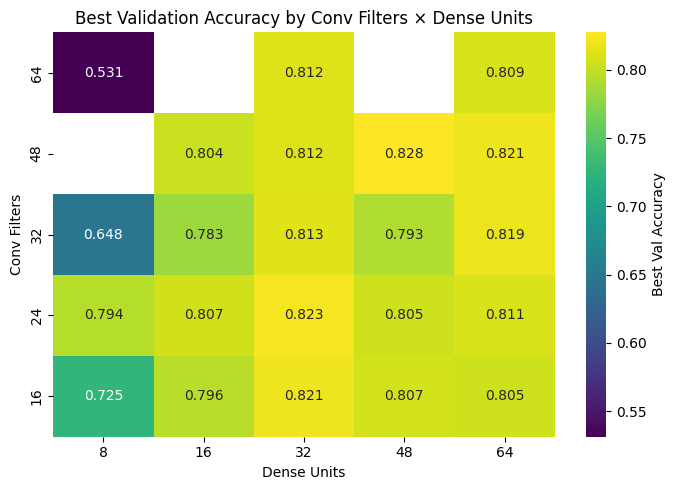

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = study.trials_dataframe()

# Keep only completed trials (drop pruned/failed ones)
df = df[df['state'] == 'COMPLETE']

# Pivot: best val_accuracy for each (conv_filters, dense_units) combination
pivot = df.pivot_table(
    index='params_conv_filters',
    columns='params_dense_units',
    values='value',
    aggfunc='max',
)

# Sort axes numerically for a clean visual progression
pivot = pivot.sort_index(ascending=False)
pivot = pivot[sorted(pivot.columns)]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='viridis',
    cbar_kws={'label': 'Best Val Accuracy'},
    ax=ax,
)
ax.set_xlabel('Dense Units')
ax.set_ylabel('Conv Filters')
ax.set_title('Best Validation Accuracy by Conv Filters × Dense Units')
plt.tight_layout()
plt.show()

## Save Results

In [56]:
df.to_csv('Studies/study_2.csv', index=False)